## Watershed Averaging

Watershed averaged variables provide useful information for situational awareness. This tutorial shows how to obtain layers from GeoMet-WCS in tiff format, crop with a shapefile, and average the corresponding watershed data.

In [1]:
# Load required packages
import numpy as np
import matplotlib.pyplot as plt
import datetime
from datetime import datetime, timedelta
import warnings
import geopandas as gp
import rioxarray
import requests
import matplotlib.pyplot as plt
import os
import re
import tempfile
import requests
import rioxarray
import os
import numpy as np
from concurrent.futures import ThreadPoolExecutor
from tqdm import tqdm
import pandas as pd
import hvplot.pandas

# web map services 
from owslib.wms import WebMapService
from owslib.wcs import WebCoverageService

# filter warnings
warnings.filterwarnings('ignore', module='owslib', category=UserWarning)
warnings.filterwarnings(action='ignore', category=FutureWarning)

## Step 1: Query GeoMet-WCS HRDLPS

First, we need to create a Web Coverage Service object that we can use to query for the layer of interest. For this tutorial, we are not using any hidden layers, so it isn't necessary to use any authentication information.

In [2]:
# create Web Coverage Service object
wcs = WebCoverageService(
    f'https://geo.weather.gc.ca/geomet?&SERVICE=WCS',
    version='2.0.1',
    timeout=300
)

Let's print out a list of contents of HRDLPS layers to see what is available.

In [3]:
for key in list(wcs.contents.keys()):
    if "HRDLPS" in key:
        print(key)

HRDLPS_2.5km_AirTemp
HRDLPS_2.5km_DewPointTemp
HRDLPS_2.5km_DrainageAmountThroughBaseOfSoil
HRDLPS_2.5km_LandEvap
HRDLPS_2.5km_LateralSubsurfaceRunoffAmt
HRDLPS_2.5km_Orography
HRDLPS_2.5km_RadiativeTemp
HRDLPS_2.5km_SoilLiquidWaterCont_0.3m
HRDLPS_2.5km_SoilLiquidWaterCont_0.7m
HRDLPS_2.5km_SoilLiquidWaterCont_0.15m
HRDLPS_2.5km_SoilLiquidWaterCont_0.025m
HRDLPS_2.5km_SoilLiquidWaterCont_0.075m
HRDLPS_2.5km_SoilLiquidWaterCont_1.5m
HRDLPS_2.5km_SoilLiquidWaterCont_2.5m
HRDLPS_2.5km_SurfaceRunoffAmtAllSurfaceTypes
HRDLPS_2.5km_SurfaceRunoffAmtGlaciers
HRDLPS_2.5km_SurfaceRunoffAmtSeaIce
HRDLPS_2.5km_SurfaceRunoffAmtSoil
HRDLPS_2.5km_SurfaceRunoffAmtWater


Lots of available layers we could use! For this tutorial, let's look at soil moisture: `HRDLPS_2.5km_SoilLiquidWaterCont_0.3m`

In [4]:
layer_name = 'HRDLPS_2.5km_SoilLiquidWaterCont_0.3m'

We can use WMS to get metadata information, such as the units and the default time.

In [5]:
wms = WebMapService(
    f'https://geo.weather.gc.ca/geomet?&SERVICE=WMS&LAYERS={layer_name}',
    version='1.3.0',
    timeout=300
)

To confirm what units the data is in, we can look at the full title of the layer.

In [6]:
wms[layer_name].title

'HRDLPS - Volumetric water content of liquid water in soil at 0.3m below the surface [m^3/m^3]'

If we don't specify a time in a WCS request, this will automatically give us the default time. Let's take a look and see what the default time is.

In [7]:
# show default time
wms[layer_name].dimensions['time']['default']

'2025-09-04T13:00:00Z'

We can now get the data from a Web Coverage Service Request.

To find the coordinate reference system (CRS) that should be specified in the WCS request, we can look at a [Describe Coverage request](https://geo.weather.gc.ca/geomet?SERVICE=WCS&VERSION=2.0.1&REQUEST=DescribeCoverage&COVERAGEID=HRDLPS_2.5km_SoilLiquidWaterCont_0.3m). This shows us `srsName="http://www.opengis.net/def/crs/EPSG/0/4326"`

In [8]:
response = wcs.getCoverage(
    identifier = [layer_name], 
    format = 'image/tiff',
    subsettingcrs ='EPSG:4326',
)

When we requested the tiff file, we were given a URL. However, to work with this data in Python, we need to create a temp file of this tiff in our working directory.

In [9]:
# define the url
url = response.geturl()

# create the temporary file
with open("temp.tif", "wb") as f:
    f.write(requests.get(url).content)

# open the tiff
hrdlps = rioxarray.open_rasterio("temp.tif")

In [10]:
hrdlps

<xarray.DataArray (band: 1, y: 1290, x: 2540)> Size: 13MB
[3276600 values with dtype=float32]
Coordinates:
  * band         (band) int32 4B 1
  * x            (x) float64 20kB -152.7 -152.7 -152.7 ... -40.8 -40.76 -40.72
  * y            (y) float64 10kB 70.6 70.57 70.53 70.5 ... 27.37 27.33 27.3
    spatial_ref  int32 4B 0
Attributes:
    AREA_OR_POINT:           Area
    TIFFTAG_RESOLUTIONUNIT:  2 (pixels/inch)
    TIFFTAG_XRESOLUTION:     72
    TIFFTAG_YRESOLUTION:     72
    scale_factor:            1.0
    add_offset:              0.0

## Step 2: For one station of interest, load its associated shapefile

First, let's choose our station of interest for this analysis. Here, we will look at station number 02EA011, corresponding to Magnetawan River Near Britt.

In [11]:
# 02EA011, MAGNETAWAN RIVER NEAR BRITT
station_num = '02EA011'

For this tutorial, the shapefile we are interested in is called `MDA_ADP_02_DrainageBasin_BassinDeDrainage.shp` and can be downloaded [here](https://collaboration.cmc.ec.gc.ca/cmc/hydrometrics/www/HydrometricNetworkBasinPolygons/). The link contains the shapefiles for the 11 Major Drainage Areas of Canada. Within each of these files, there are further subdivisions of drainaige areas for each specific station, specified by their station numbers.

In [13]:
# Open the shapefile with geopandas
shp_file = gp.read_file(r'shapefile/MDA_ADP_02_DrainageBasin_BassinDeDrainage.shp') 

# view data
shp_file.head()

,StationNum,NameNom,Status,Etat,Area_km2,Aire_km2,Remark,Remarque,Version,Date_rev,Shape_Leng,Shape_Area,geometry
0,02AA001,PIGEON RIVER AT MIDDLE FALLS,discontinued,fermée,1573.72,1573.72,None,None,June 2024 / juin 2024,2024-06-01,366480.0,1.573723e+09,"POLYGON ((447750 883800, 447780 883800, 447780..."
1,02AA002,PINE RIVER NEAR CROOKS,discontinued,fermée,392.45,392.45,None,None,June 2024 / juin 2024,2024-06-01,176700.0,3.924504e+08,"POLYGON ((469740 906510, 469800 906510, 469800..."
2,02AB001,KAMINISTIQUIA RIVER NEAR DONA,discontinued,fermée,3565.15,3565.15,None,None,June 2024 / juin 2024,2024-06-01,766140.0,3.565148e+09,"POLYGON ((465420 976290, 465420 976320, 465450..."
3,02AB002,SHEBANDOWAN RIVER NEAR KAMINISTIQUIA,discontinued,fermée,2902.91,2902.91,None,None,June 2024 / juin 2024,2024-06-01,546900.0,2.902905e+09,"POLYGON ((465420 976290, 465390 976290, 465390..."
4,02AB003,KAMINISTIQUIA RIVER AT MOKOMON,discontinued,fermée,6644.57,6644.57,None,None,June 2024 / juin 2024,2024-06-01,1141320.0,6.644574e+09,"POLYGON ((422190 1027230, 422190 1027200, 4222..."


There are thousands of stations within this shapefile! Selecting the station of interest will provide us with the watershed specific to that station.

In [14]:
# select for the station of interest
station_shp = shp_file[shp_file['StationNum']==station_num]
station_shp

,StationNum,NameNom,Status,Etat,Area_km2,Aire_km2,Remark,Remarque,Version,Date_rev,Shape_Leng,Shape_Area,geometry
182,02EA011,MAGNETAWAN RIVER NEAR BRITT,active,en service,2837.91,2837.91,None,None,June 2024 / juin 2024,2024-06-01,791340.0,2.837911e+09,"POLYGON ((1264920 761370, 1264950 761370, 1264..."


It is important to determine the CRS of the watershed shapefile so that we can ensure consistency between the watershed shapefile and the HRDLPS layer.

In [15]:
# retrieve the shapefile geometry and its CRS
geometries_shp = station_shp.geometry.values
crs_shp = station_shp.crs

# display the crs
crs_shp

<Projected CRS: ESRI:102001>
Name: Canada_Albers_Equal_Area_Conic
Axis Info [cartesian]:
- [east]: Easting (metre)
- [north]: Northing (metre)
Area of Use:
- undefined
Coordinate Operation:
- name: unnamed
- method: Albers Equal Area
Datum: North American Datum 1983
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

We can see that the shapefile is in a projected CRS of ESRI:102001, also known as Canada Albers Equal-Area Conic projection. This is different than the CRS of the HRDLPS data (EPSG:4326), meaning that we need to transform the HRDLPS data coordinate systems to match that of the shapefile so that we can properly crop the data. It is prefereable to have our data in a projected CRS for better accuracy.

In [16]:
# Change hrdlps into the same projected CRS as the shapefile
hrdlps_reproj = hrdlps.rio.reproject(crs_shp)

## Step 3: Crop the HRDLPS data to the shapefile

First, we can visualize where our watershed of interest is by plotting the shapefile on top of the HRDLPS data.

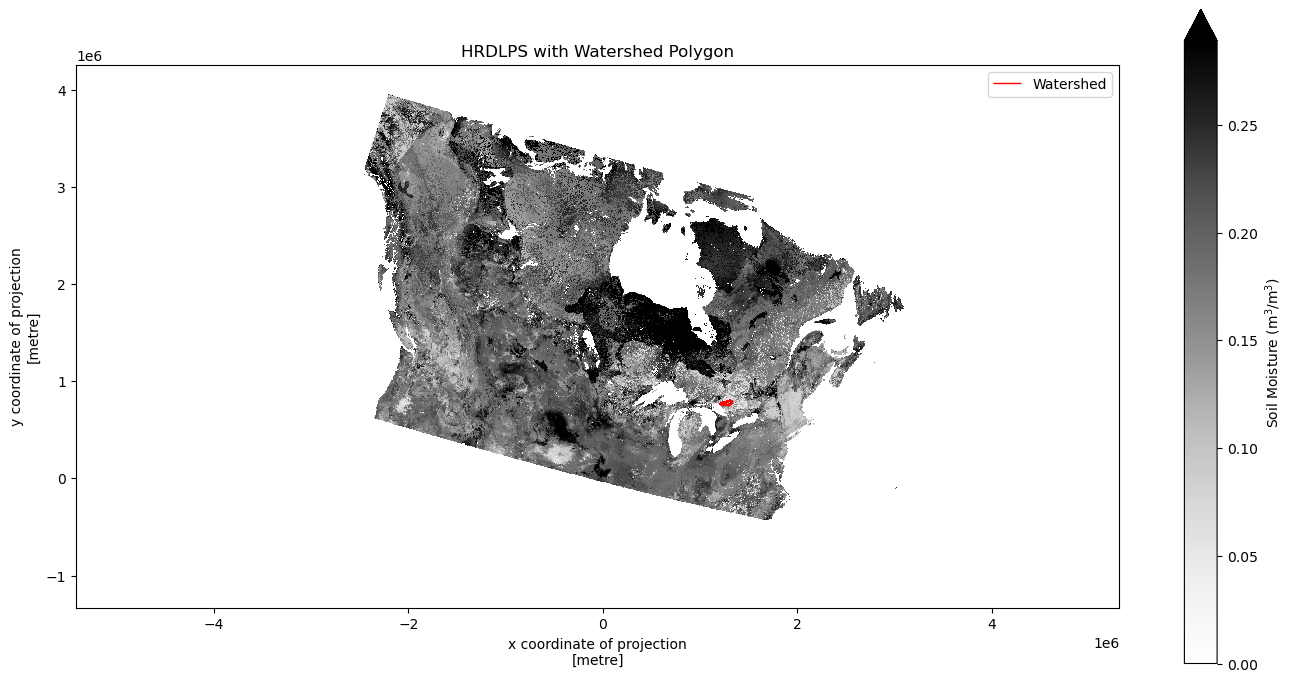

In [17]:
# Plot
fig, ax = plt.subplots(figsize=(14, 7))

# Show the raster
hrdlps_reproj.sel(band=1).plot(ax=ax, cmap='Greys', add_colorbar=True, robust=True,
                          cbar_kwargs={'label': 'Soil Moisture (m$^3$/m$^3$)'})

# Overlay the watershed shapefile
station_shp.boundary.plot(ax=ax, color='red', linewidth=1, label='Watershed')

ax.set_title("HRDLPS with Watershed Polygon")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

With the HRDLPS data and the watershed shapefile in the same projected CRS, we can clip the HRDLPS data to the shapefile. This way, we will only be working with the HRDLPS data specific to the station's watershed.

To note: if an HRDLPS pixel is only partially covered by the shapefile, it will be kept if the center or the pixel is within the polygon or selected by Bresenham's line algorithm. If all pixels touched by the shapefile are wanted, include `all_touched=True`. Please read more about his [here](https://corteva.github.io/rioxarray/stable/rioxarray.html#rioxarray.raster_dataset.RasterDataset.clip).

In [18]:
hrdlps_clipped = hrdlps_reproj.rio.clip(geometries_shp, crs_shp, drop=True)

Now, let's visualize what the cropped HRDLPS data looks like.

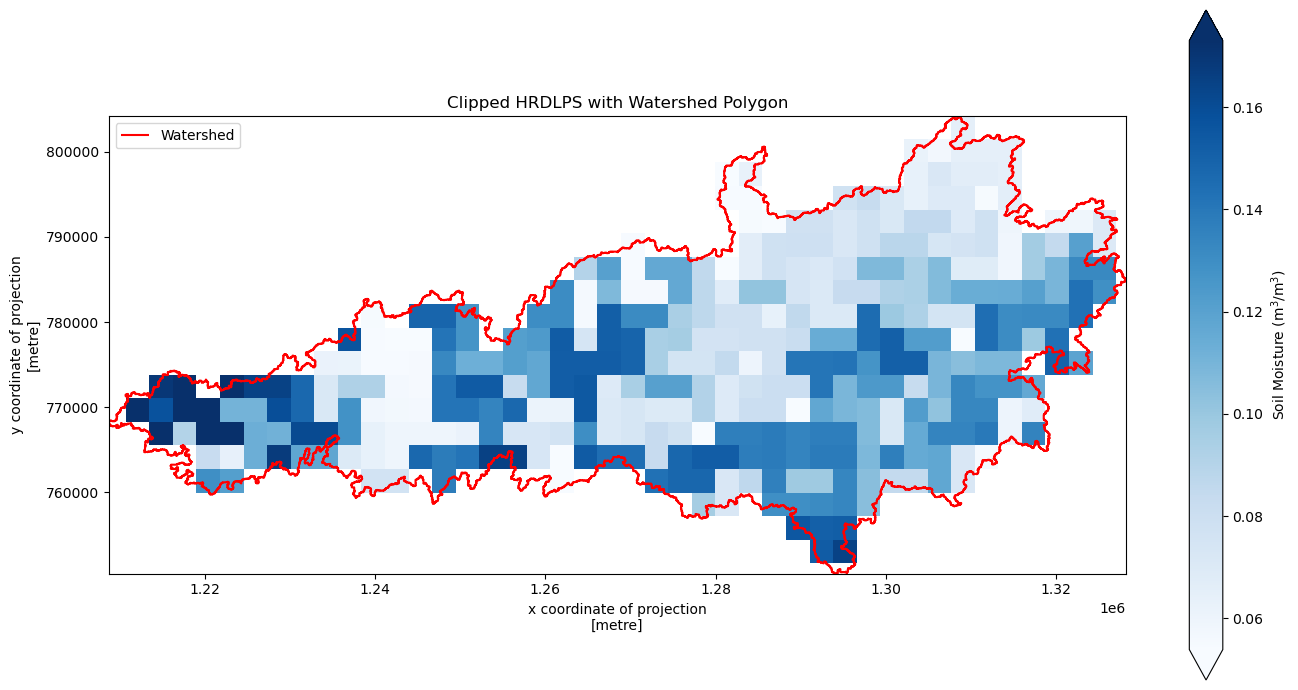

In [19]:
# Plot
fig, ax = plt.subplots(figsize=(14, 7))

# Show the raster
hrdlps_clipped.sel(band=1).plot(ax=ax, cmap='Blues', add_colorbar=True, robust=True,
                          cbar_kwargs={'label': 'Soil Moisture (m$^3$/m$^3$)'})

# Overlay the watershed shapefile
station_shp.boundary.plot(ax=ax, color='red', linewidth=1.5, label='Watershed')

# Set plot limits to watershed boundary
minx, miny, maxx, maxy = station_shp.total_bounds
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

ax.set_title("Clipped HRDLPS with Watershed Polygon")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

## Step 4: Watershed Averaging

Now that the HRDLPS data is croppped to the watershed of interest, we can average the pixels in the watershed.

In [20]:
hrdlps_avg = np.nanmean(hrdlps_clipped)
print("The average 0.3 m soil moisture for the watershed of station number "+station_num+" is "+str(hrdlps_avg)+" m\u00B3/m\u00B3.")

The average 0.3 m soil moisture for the watershed of station number 02EA011 is 0.10341195 m³/m³.


Now that we are done with the temp tiff file, let's delete it to avoid accumulating files in our working directory.

In [21]:
# close and remove the temp file
hrdlps.close()
os.remove("temp.tif")

## Step 5: Time Series

Now that we know the workflow that is needed to obtain a watershed average, we can loop over multiple dates of the layer of interest to create a time series of averaged HRDLPS data.

First, we need to find which dates we will be looping over. Looking at the WMS time dimensions shows us the first and last dates that are available, and the datetime interval. From this information, we can create a list of all available dates.

In [22]:
first_datetime, last_datetime, datetime_interval = wms[layer_name].dimensions['time']['values'][0].split('/')
print(wms[layer_name].dimensions['time']['values'][0].split('/'))

['2025-09-04T00:00:00Z', '2025-09-10T00:00:00Z', 'PT1H']


In [23]:
iso_format = "%Y-%m-%dT%H:%M:%SZ"

# convert dates to datetime objects
first = datetime.strptime(first_datetime, iso_format)
last = datetime.strptime(last_datetime, iso_format)

# remove anything that isn't a number from the datetime interval
intvl = int(re.sub(r'\D', '', datetime_interval))

# create a list of datetimes (we will add these to the requested data)
hrdlps_hrs = [first]
while first < last:
    first = first + timedelta(hours=intvl)
    hrdlps_hrs.append(first)

# create a list of iso formatted forecast datetime strings (we will use these in the WCS requests)
hrdlps_hrs_str = [datetime.strftime(hr, iso_format) for hr in hrdlps_hrs]

We can create a function that we can use to loop over the wanted dates to request, transform, crop, and average the layer data. 

In [24]:
def watershed_avg(hr, layer_name, crs_shp, geometries_shp):
    # query wcs
    response = wcs.getCoverage(identifier=[layer_name], 
                          format='image/tiff', 
                          subsettingcrs='EPSG:4326',
                          TIME=hr)
    # define URL of Tiff
    url = response.geturl()

    # Download file as bytes (this is in memory and atomic)
    tiff_bytes = requests.get(url).content
    
    # create a unique temp file (otherwise temp files will be overwritten)
    with tempfile.NamedTemporaryFile(suffix=".tif", delete=False) as tmp:
        temp_path = tmp.name
        tmp.write(tiff_bytes)
    
    try:
        with rioxarray.open_rasterio(temp_path) as da:
            # reproject HRDLPS data
            da_reproj = da.rio.reproject(crs_shp)
            # crop to the watershed shapefile
            da_clipped = da_reproj.rio.clip(geometries_shp, crs_shp, drop=True)
            # average watershed data
            da_avg = np.nanmean(da_clipped)
    finally:
        # remove temp file
        os.remove(temp_path)
    
    return da_avg

Doing all this in a loop can be time consuming, so parallelization is recommended to speed up the workflow. However, even with parallelization, the cell may take around 5 minutes to run.

Please note that if you get a warning of `NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned`, you should start the parallelization over again. Occasionally the data is not opened properly, which may result in incorrect values, but this shouldn't happen every time.

In [25]:
# create an empty list to append the results to
results = []

# start parallelization
with ThreadPoolExecutor(max_workers=6) as executor:
    # submit tasks in order, collect futures in a list
    futures = [executor.submit(watershed_avg, hr, layer_name, crs_shp, geometries_shp) for hr in hrdlps_hrs_str]
    # this preserves the order of dates
    for future in tqdm(futures, total=len(futures)):
        results.append(future.result())

100%|██████████| 145/145 [05:22<00:00,  2.23s/it]


Now we can plot to visualize this time series data.

In [26]:
# transform into a dataframe so that we can use hvplot
df = pd.DataFrame({'Date': hrdlps_hrs, 'Soil Moisture': results})

In [27]:
# create interactive plot
df.hvplot(
    x='Date',
    y='Soil Moisture',
    width=900, 
    height=500,
    title=f'Station {station_num} Watershed Average',
    ylabel='Soil Moisture (m³/m³)', 
    xlabel='Date',
    line_width=2,
    grid=True
)

:Curve   [Date]   (Soil Moisture)